<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [ ]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
#file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv("survey_data_with_duplicate.csv ")

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [7]:
## Write your code here
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

duplicates = df[df.duplicated(keep=False)]
print(f"\nTotal rows involved in duplication: {len(duplicates)}")
print(duplicates.head())

Number of duplicate rows: 20

Total rows involved in duplication: 40
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                    

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [9]:
## Write your code here
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Group by these columns and count how many respondents share the same pattern
pattern_groups = df.groupby(pattern_cols).size().reset_index(name='Count')
pattern_groups = pattern_groups.sort_values('Count', ascending=False)
print("Top shared response patterns:\n", pattern_groups.head())

# Find which other columns frequently have identical values within these groups
df['pattern_group'] = df.groupby(pattern_cols).ngroup()

# Count unique values per column within each group
print("\nColumns that vary LEAST within response pattern groups (most similar):")
for col in df.columns:
    if col not in pattern_cols + ['pattern_group']:
        uniqueness = df.groupby('pattern_group')[col].nunique().mean()
        print(f"  {col}: avg unique values per group = {uniqueness:.2f}")

Top shared response patterns:
                         MainBranch  \
0   I am a developer by profession   
2   I am a developer by profession   
1   I am a developer by profession   
78  I am a developer by profession   
8   I am a developer by profession   

                                           Employment  \
0                                 Employed, full-time   
2                                 Employed, full-time   
1                                 Employed, full-time   
78  Independent contractor, freelancer, or self-em...   
8   Employed, full-time;Independent contractor, fr...   

                              RemoteWork  Count  
0   Hybrid (some remote, some in-person)  15288  
2                                 Remote  12196  
1                              In-person   7118  
78                                Remote   2815  
8                                 Remote   1754  

Columns that vary LEAST within response pattern groups (most similar):
  ResponseId: avg unique 

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


C:\TEMP\ipykernel_7948\900685721.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared['Country'] = shared['Country'].replace({


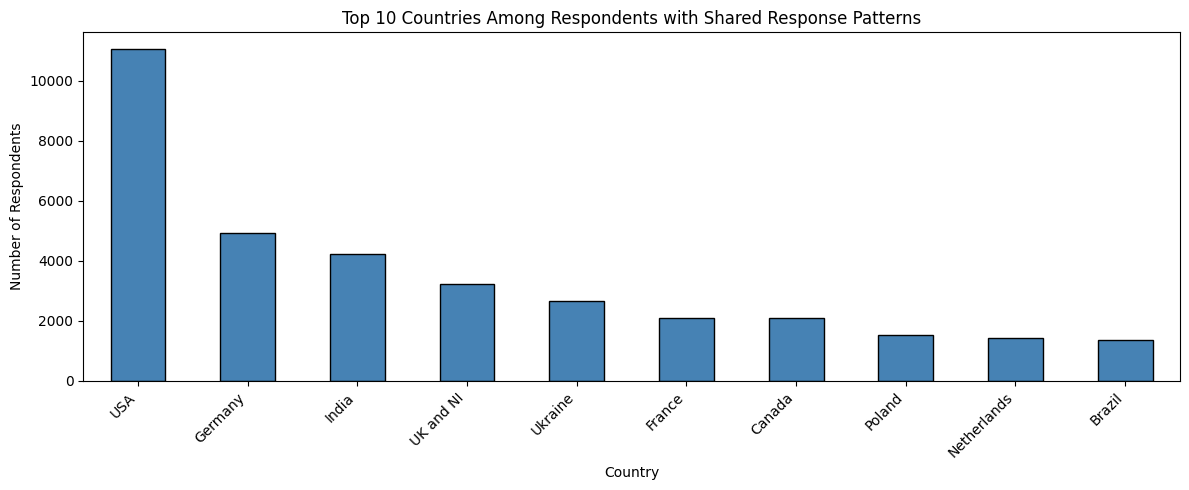

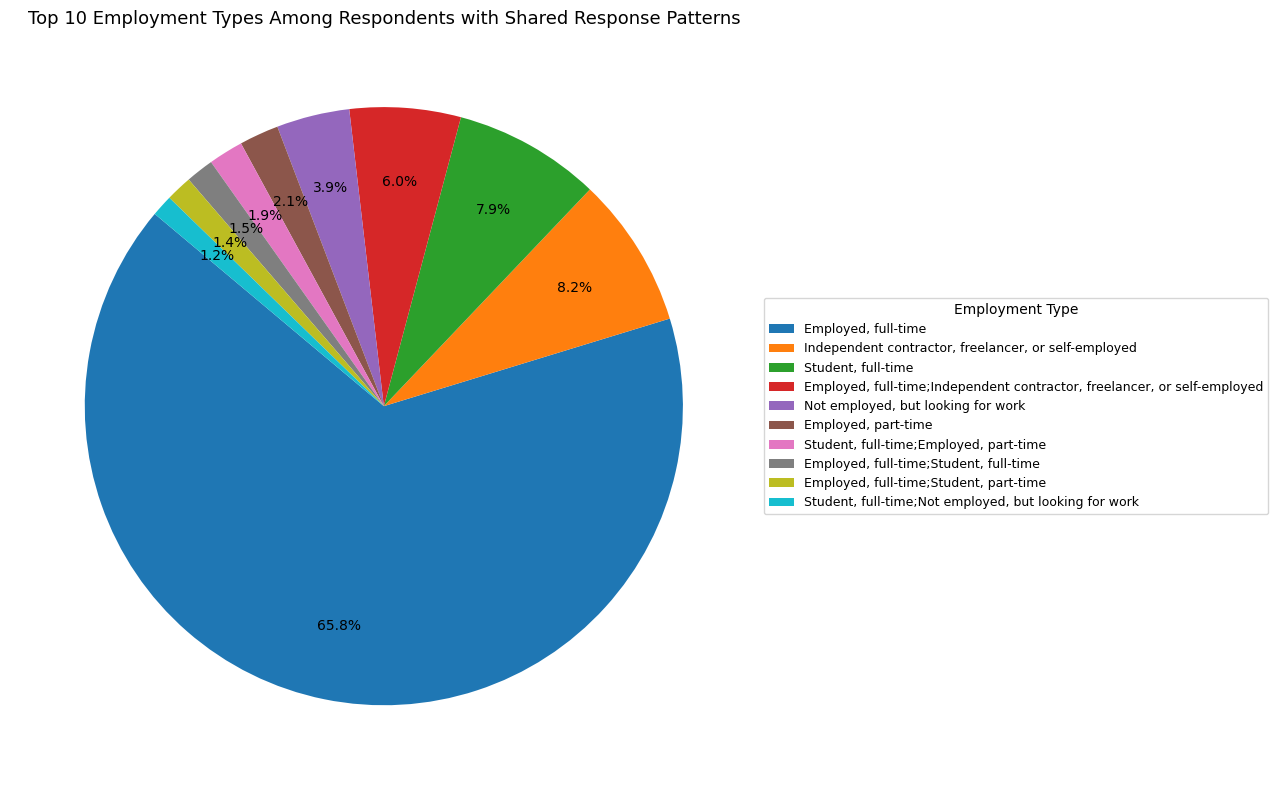

In [17]:
## Write your code here
import matplotlib.pyplot as plt

# --- Bar Chart: Top Countries among respondents sharing identical patterns ---
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']
shared = df[df.duplicated(subset=pattern_cols, keep=False)]

shared['Country'] = shared['Country'].replace({
    'United States of America': 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK and NI'
})

# Plot 1: Distribution by Country
top_countries = shared['Country'].value_counts().head(10)
plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='steelblue', edgecolor='black') 
plt.title('Top 10 Countries Among Respondents with Shared Response Patterns')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_country.png')
plt.show()

# --- Pie Chart: Top 10 Employment types among shared response patterns ---
top_10_employment = shared['Employment'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14, 8))
wedges, texts, autotexts = ax.pie(
    top_10_employment,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.tab10.colors,
    pctdistance=0.75
)

# Add legend to the right side
ax.legend(
    wedges,
    top_10_employment.index,
    title="Employment Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)

ax.set_title('Top 10 Employment Types Among Respondents with Shared Response Patterns', fontsize=13)
plt.tight_layout()
plt.savefig('chart_top10_employment_pie_legend.png', bbox_inches='tight')
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
